# Create Region Embeddings from seqlet annotations

Required:
- Crucial: tf mindi seqlet adata with pca/vea reduced seqlet embeddings
- When finding optimal clustering: cell_type column or column demarcating other types of region groups in .obs
- When wheighted embedding (default, recommended): attribution score of the seqlet in .obs
- When making region cluster motif profiles: annotation column in .obs for 

In [1]:
import tfmindi as tm

/home/VIB.LOCAL/bram.stuyven/miniforge3/envs/MINDI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# seqlet_adata = tm.load_h5ad("path/to/pbmc.h5ad")
seqlet_adata = tm.load_h5ad('/data/groups/vib.ai/stein.aerts/sdewin/PhD/papers/TF_MINDI/tfbs_atlas/total_annotated/pbmc.h5ad')

attribution, cell type and annotation column:

In [3]:
seqlet_adata.obs[['attribution','cell_type','predicted_5.0_predicted_family_no_cl']].head()

,attribution,cell_type,predicted_5.0_predicted_family_no_cl
0,1.200954,Cytotoxic_T_cell,Runt
1,2.519469,Cytotoxic_T_cell,Runt
2,1.610592,Cytotoxic_T_cell,Runt
3,2.066564,Cytotoxic_T_cell,MYB
4,1.751482,Cytotoxic_T_cell,T-box


### Create region embeddings using pca reducions

In [4]:
region_adata = tm.tl.embed_regions(seqlet_adata)

 [embed] Calculating weights
 [embed] Calculating pca embeddings on obsm.X_pca
 [embed] Calculating TSNE reduction...


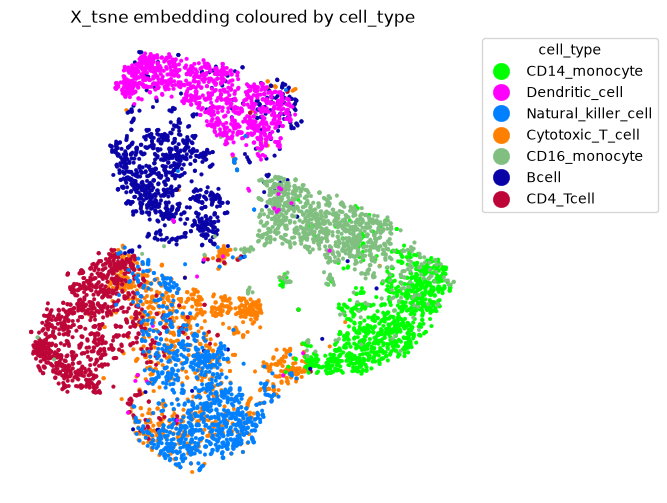

In [ ]:
palette = tm.pl.tsne(region_adata, color_by='cell_type')

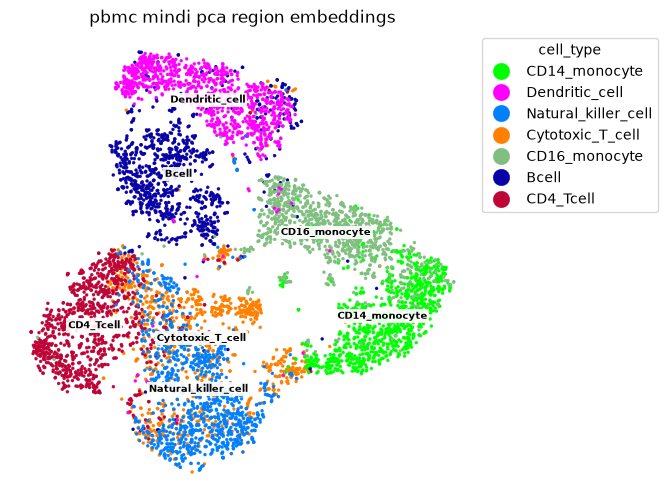

In [7]:
_ = tm.pl.tsne(region_adata, obsm_key='X_tsne', color_by='cell_type', title="pbmc mindi pca region embeddings",
                                    plot_legend=False, plot_labels=True, palette=palette, fig_edge=6, dot_size=5, clean=True)

### Count vector embeddings

In [9]:
region_adata_count = tm.tl.embed_regions(seqlet_adata, embedding="count", secondary='predicted_5.0_predicted_family', normalised=False)

 [embed] Calculating weights
 [embed] Calculating count embeddings by constructing count vectors at adata.obs['predicted_5.0_predicted_family'] resolution
 [embed] Calculating TSNE reduction...


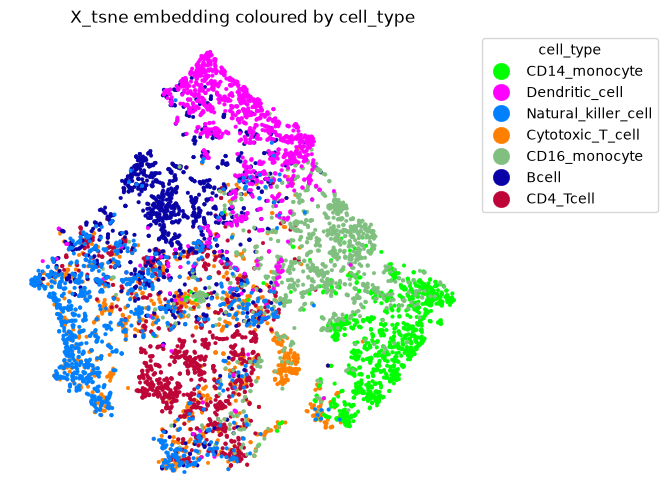

In [11]:
_ = tm.pl.tsne(region_adata_count, color_by='cell_type', palette=palette)

### Using previous cell type labels to find best clustering of the enbeddings

 [clustering] Seeding embedding space with leiden clusters...
 [clustering] Build hierarchical tree...
 [clustering] Cutting at height 0.99
 [clustering] The optimal resolution is 0.44 with an ARI of 0.4406877298115642
 [clustering] Saved clusters in .obs region_cluster
 [clustering] Plotting...


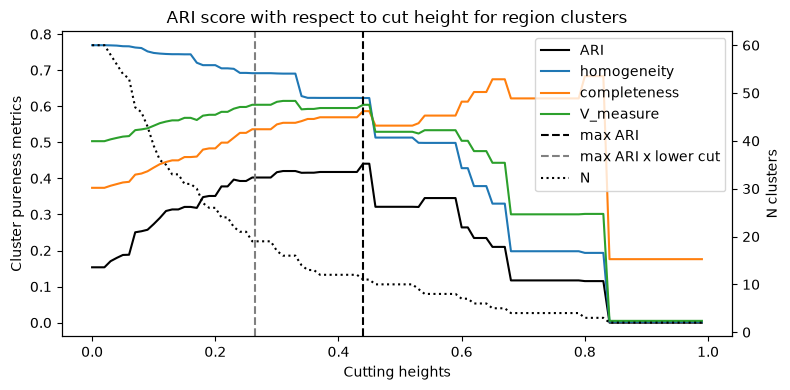

In [12]:
tm.tl.optimal_hierarchical_clustering(region_adata, lower_cut=0.6)

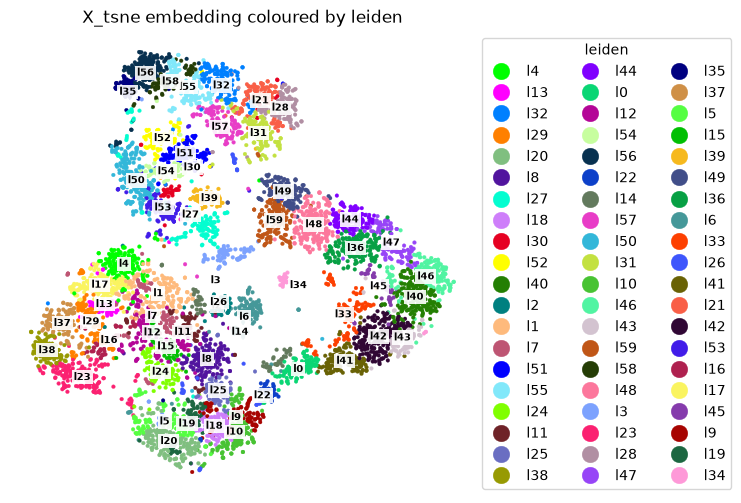

In [13]:
_ = tm.pl.tsne(region_adata, color_by='leiden', plot_legend=True, plot_labels=True)

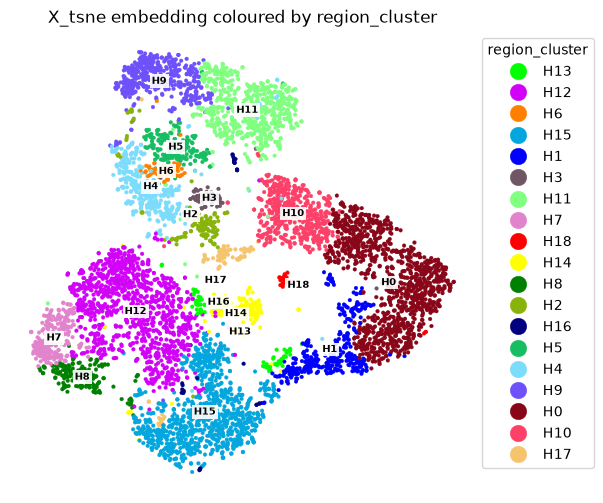

In [14]:
_ = tm.pl.tsne(region_adata, color_by='region_cluster', plot_legend=True, plot_labels=True)

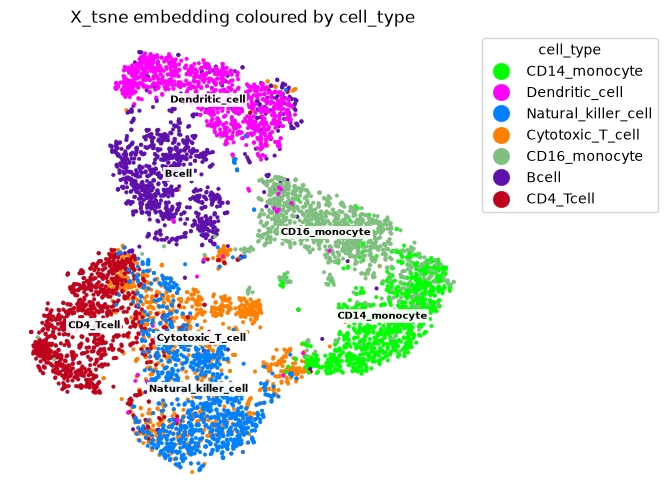

In [16]:
_ = tm.pl.tsne(region_adata, color_by='cell_type', plot_legend=True, plot_labels=True)

### Gather region cluster profiles

In [17]:
profiles = tm.tl.get_region_profiles(seqlet_adata, region_adata, annotation_col='predicted_5.0_predicted_family_no_cl', region_cluster_col='region_cluster')

/home/VIB.LOCAL/bram.stuyven/miniforge3/envs/MINDI/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


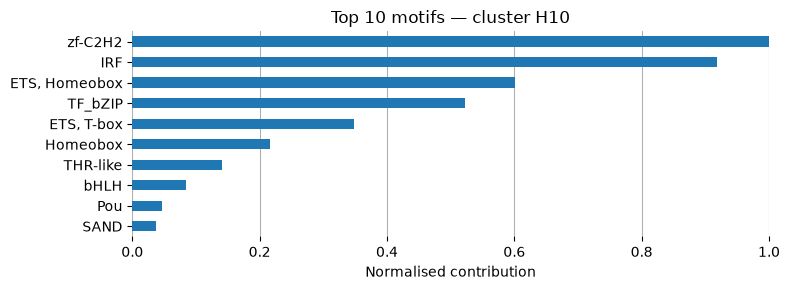

In [18]:
tm.pl.plot_top_motifs(profiles, region_cluster='H10')

### Save region object

In [19]:
tm.save_h5ad(region_adata, "temp_dev_regions_pbmc.h5ad")